## 1 — Imports & helpers

In [31]:
import fitdecode
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from datetime import datetime, timedelta, timezone
from math import radians, sin, cos, sqrt, atan2
import warnings
warnings.filterwarnings('ignore')

R_EARTH = 6371.0  # km

def semicircles_to_deg(v):
    return v * (180.0 / 2**31)

def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    return R_EARTH * 2 * atan2(sqrt(a), sqrt(1 - a))

def build_cum_dist(lats, lons):
    d = [0.0]
    for i in range(1, len(lats)):
        d.append(d[-1] + haversine_km(lats[i-1], lons[i-1], lats[i], lons[i]))
    return np.array(d)

print('Imports OK')

Imports OK


## 2 — Load FIT file

In [113]:
FIT_PATH = 'track.fit'

records, laps_raw = [], []
with fitdecode.FitReader(FIT_PATH) as fit:
    for frame in fit:
        if frame.frame_type != fitdecode.FIT_FRAME_DATA:
            continue

        if frame.name == 'record':
            row = {f.name: f.value for f in frame.fields}
            records.append(row)

        elif frame.name == 'lap':
            lap = {f.name: f.value for f in frame.fields}
            laps_raw.append(lap)

df = pd.DataFrame(records)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

# Convert semicircle coordinates to degrees
for col in ['position_lat', 'position_long']:
    if col in df.columns:
        df[col] = df[col].apply(lambda x: semicircles_to_deg(x) if x is not None else np.nan)

# Rename for convenience
df = df.rename(columns={'position_lat': 'lat', 'position_long': 'lon',
                         'enhanced_altitude': 'alt', 'enhanced_speed': 'speed',
                         'heart_rate': 'hr'})

valid = df[['lat','lon']].dropna()
df['dist_km'] = np.nan

if len(valid) > 1:
    d = build_cum_dist(valid['lat'].values, valid['lon'].values)
    df.loc[valid.index, 'dist_km'] = d
    # Interpolate between valid points, then fill leading NaNs with 0
    df['dist_km'] = df['dist_km'].interpolate().fillna(0)
else:
    # If there aren't enough valid points to calculate distance, 
    # it makes sense to just default the whole column to 0
    df['dist_km'] = 0.0

# Pace (min/km)
# Pace (min/km)
if 'speed' in df.columns:
    # If 'speed' has duplicate columns, grab the first one (.iloc[:, 0])
    # Otherwise, treat it as a regular single column
    speed_col = df['speed'].iloc[:, 0] if isinstance(df['speed'], pd.DataFrame) else df['speed']
    
    # Calculate pace using the cleaned single column
    df['pace'] = 1000 / speed_col.replace(0, np.nan) / 60
    
print(f'Loaded {len(df)} records  |  {df["dist_km"].max():.2f} km total')
print(f'Duration: {df["timestamp"].iloc[-1] - df["timestamp"].iloc[0]}')
print(f'Columns available: {list(df.columns)}')
df.head(3)

Loaded 4106 records  |  8.30 km total
Duration: 0 days 01:12:24
Columns available: ['activity_type', 'timestamp', 'distance', 'hr', 'speed', 'speed', 'step_length', 'Effort Pace', 'cadence', 'power', 'accumulated_power', 'alt', 'altitude', 'lat', 'lon', 'dist_km', 'pace']


,activity_type,timestamp,distance,hr,speed,speed,step_length,Effort Pace,cadence,power,accumulated_power,alt,altitude,lat,lon,dist_km,pace
0,running,2026-05-17 16:22:17+00:00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN
1,running,2026-05-17 16:22:18+00:00,0.00,101.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN
2,running,2026-05-17 16:22:19+00:00,0.00,101.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN


## 3 — Inspect device laps

In [114]:
# Build a clean lap table with timestamps + matched distance from our GPS dist
lap_rows = []
for i, lap in enumerate(laps_raw):
    ts_start = pd.to_datetime(lap.get('start_time'))
    ts_end   = pd.to_datetime(lap.get('timestamp'))   # 'timestamp' = end time in lap messages
    # Find matching rows
    mask = (df['timestamp'] >= ts_start) & (df['timestamp'] <= ts_end)
    sub = df[mask]
    lap_rows.append({
        'lap':        i,
        'start_time': ts_start,
        'end_time':   ts_end,
        'duration_s': (ts_end - ts_start).total_seconds() if ts_start and ts_end else np.nan,
        'dist_km':    sub['dist_km'].max() - sub['dist_km'].min() if not sub.empty else 0,
        'elev_gain':  max(0, sub['alt'].diff().clip(lower=0).sum()) if 'alt' in sub else np.nan,
        'avg_hr':     sub['hr'].mean() if 'hr' in sub else np.nan,
        'avg_pace':   sub['pace'].median() if 'pace' in sub else np.nan,
        'n_pts':      len(sub),
    })

laps_df = pd.DataFrame(lap_rows)
laps_df["slope"] = (laps_df["elev_gain"] / (laps_df["dist_km"] * 1000)).replace([np.inf, -np.inf], np.nan) * 100
laps_df['duration_min'] = laps_df['duration_s'] / 60
pd.options.display.float_format = '{:.2f}'.format
print(f'{len(laps_df)} laps found')
laps_df[['lap','start_time','end_time','duration_min','dist_km','elev_gain','avg_hr','avg_pace','n_pts', "slope"]]


15 laps found


,lap,start_time,end_time,duration_min,dist_km,elev_gain,avg_hr,avg_pace,n_pts,slope
0,0,2026-05-17 16:22:17+00:00,2026-05-17 16:38:14+00:00,15.95,1.07,301.00,169.96,12.25,933,28.03
1,1,2026-05-17 16:38:14+00:00,2026-05-17 16:43:27+00:00,5.22,0.26,88.00,170.13,17.81,314,33.48
2,2,2026-05-17 16:43:27+00:00,2026-05-17 16:46:37+00:00,3.17,0.26,49.00,169.37,11.47,191,19.14
3,3,2026-05-17 16:46:37+00:00,2026-05-17 16:48:19+00:00,1.70,0.10,28.00,166.59,16.36,103,27.17
4,4,2026-05-17 16:48:19+00:00,2026-05-17 16:49:29+00:00,1.17,0.10,14.00,167.69,9.72,71,13.62
5,5,2026-05-17 16:49:29+00:00,2026-05-17 16:54:52+00:00,5.38,0.62,29.00,158.52,6.55,284,4.70
6,6,2026-05-17 16:54:52+00:00,2026-05-17 16:57:06+00:00,2.23,0.24,32.00,161.11,8.62,135,13.37
7,7,2026-05-17 16:57:06+00:00,2026-05-17 16:57:20+00:00,0.23,0.02,0.00,165.13,10.49,15,0.00
8,8,2026-05-17 16:57:20+00:00,2026-05-17 16:58:59+00:00,1.65,0.24,15.00,166.61,6.60,100,6.32
9,9,2026-05-17 16:58:59+00:00,2026-05-17 16:59:58+00:00,0.98,0.05,17.00,166.50,16.49,60,31.91


## 4 — Overview plot: all laps on elevation + map

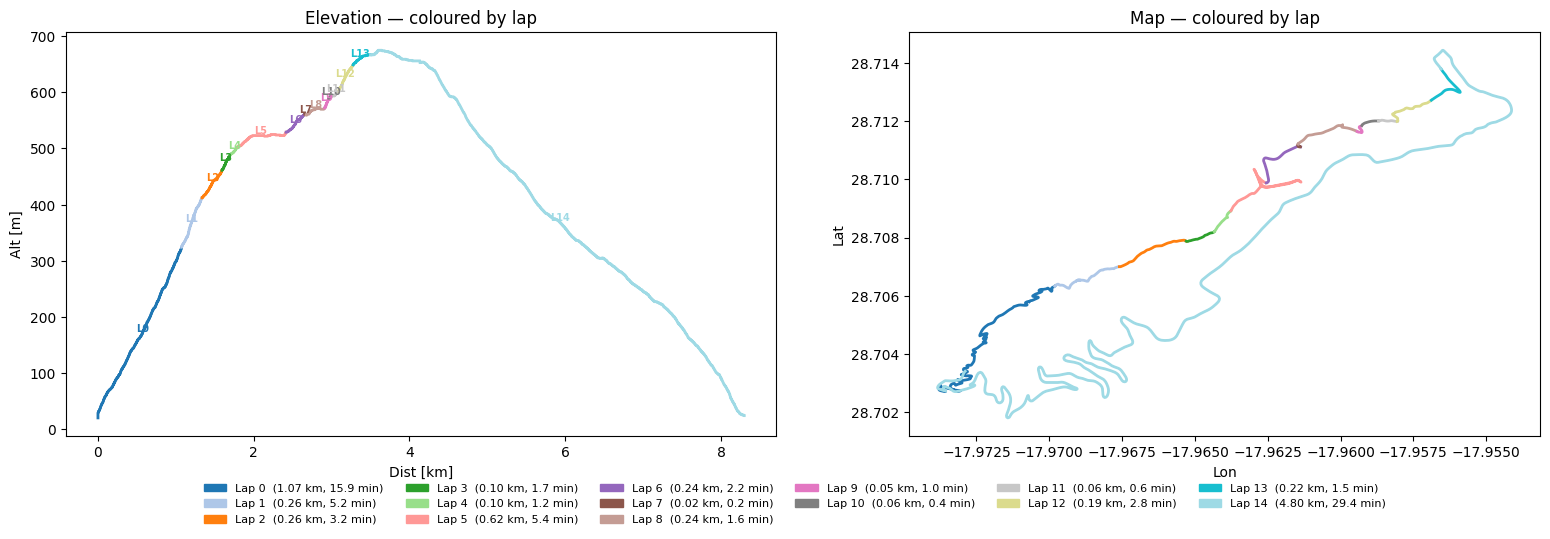

In [115]:
LAP_COLORS = plt.cm.tab20(np.linspace(0, 1, max(len(laps_df), 1)))

fig, (ax_elev, ax_map) = plt.subplots(1, 2, figsize=(16, 5))

# Background full trace
ax_elev.plot(df['dist_km'], df['alt'], color='lightgrey', lw=1.5, zorder=1)
ax_map.plot(df['lon'], df['lat'], color='lightgrey', lw=1, zorder=1)

patches = []
for _, row in laps_df.iterrows():
    i = int(row['lap'])
    color = LAP_COLORS[i % len(LAP_COLORS)]
    mask = (df['timestamp'] >= row['start_time']) & (df['timestamp'] <= row['end_time'])
    sub = df[mask]
    if sub.empty: continue
    ax_elev.plot(sub['dist_km'], sub['alt'], color=color, lw=2, zorder=2)
    ax_map.plot(sub['lon'], sub['lat'], color=color, lw=2, zorder=2)
    # Label at midpoint
    mid = len(sub) // 2
    ax_elev.text(sub['dist_km'].iloc[mid], sub['alt'].iloc[mid], f'L{i}',
                 fontsize=7, ha='center', va='bottom', color=color, fontweight='bold')
    patches.append(mpatches.Patch(color=color, label=f'Lap {i}  ({row["dist_km"]:.2f} km, {row["duration_min"]:.1f} min)'))

ax_elev.set_xlabel('Dist [km]'); ax_elev.set_ylabel('Alt [m]'); ax_elev.set_title('Elevation — coloured by lap')
ax_map.set_xlabel('Lon'); ax_map.set_ylabel('Lat'); ax_map.set_title('Map — coloured by lap')
ax_map.set_aspect('equal')
fig.legend(handles=patches, loc='lower center', ncol=6, fontsize=8, frameon=False, bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.savefig('overview_laps.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 — Plot individual laps (one per plot for inspection)

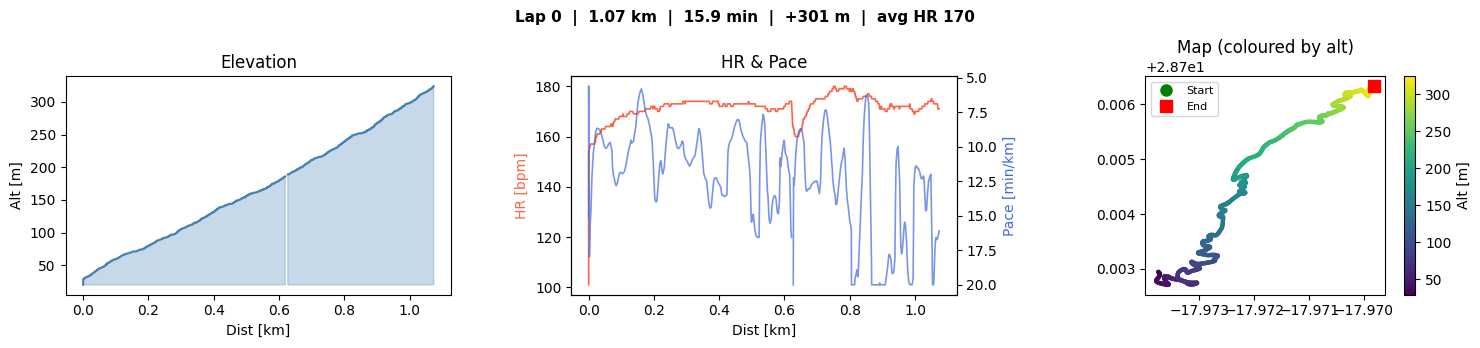

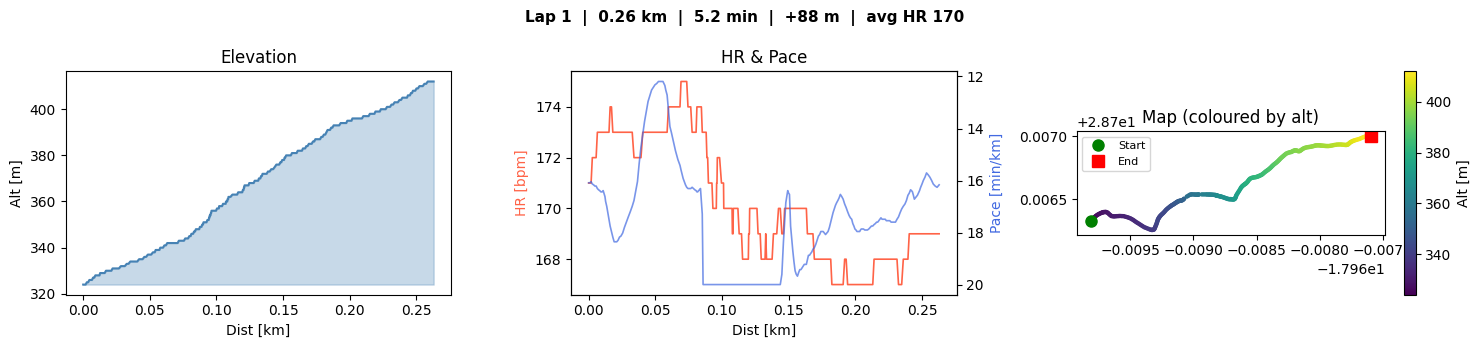

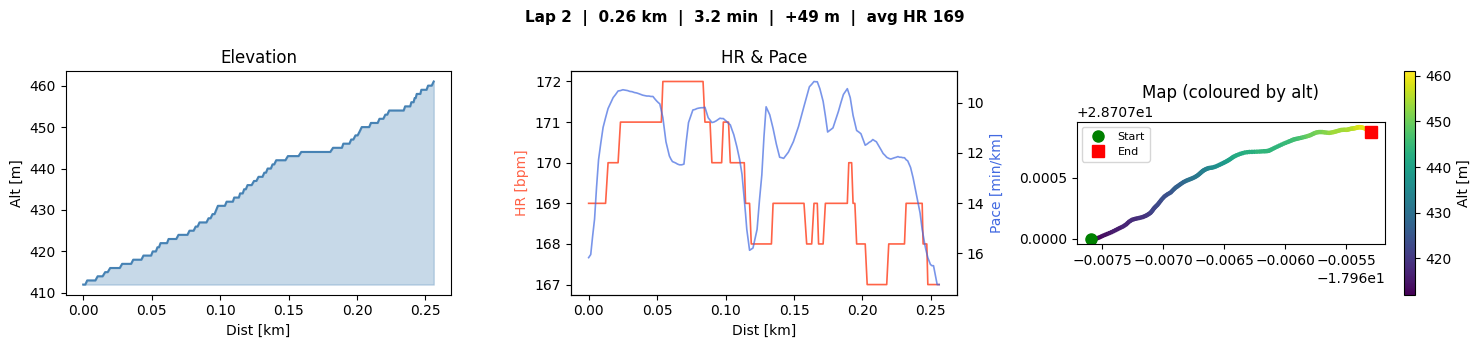

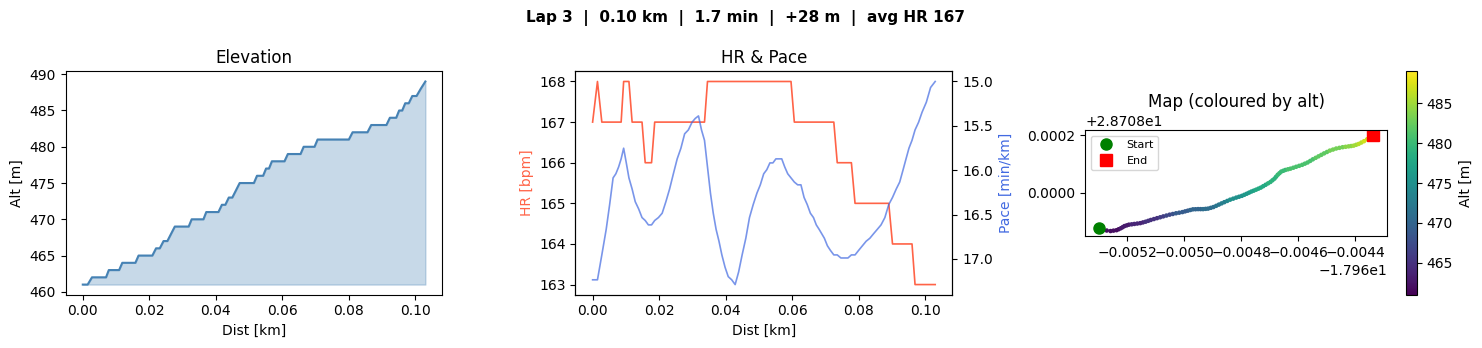

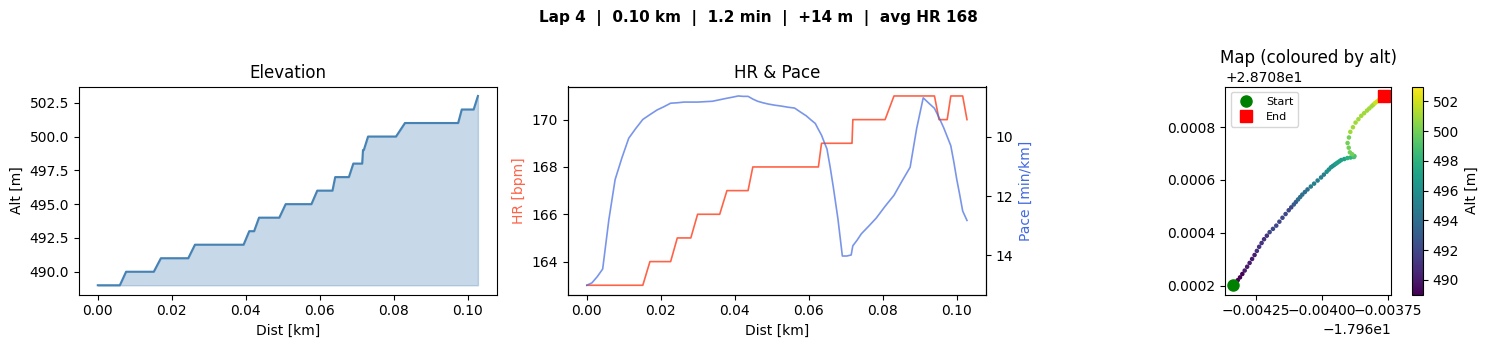

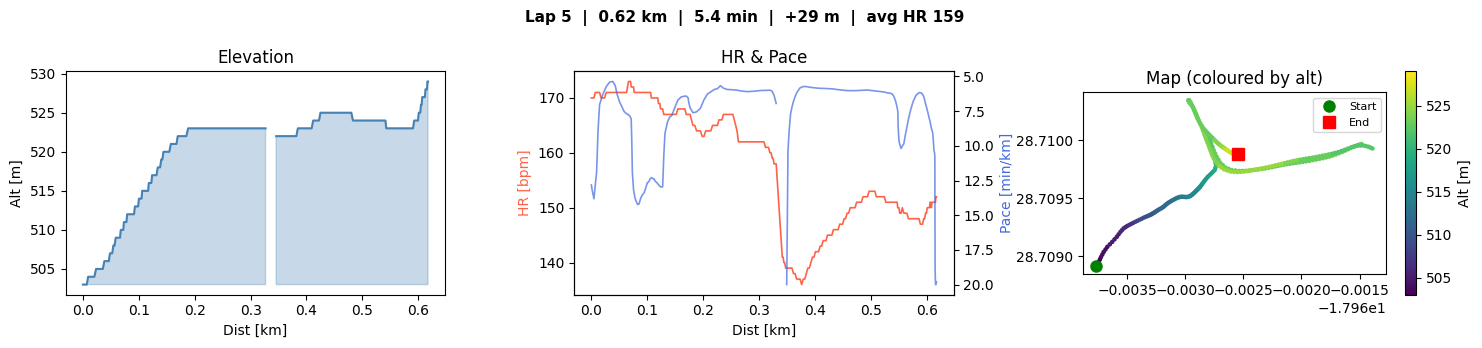

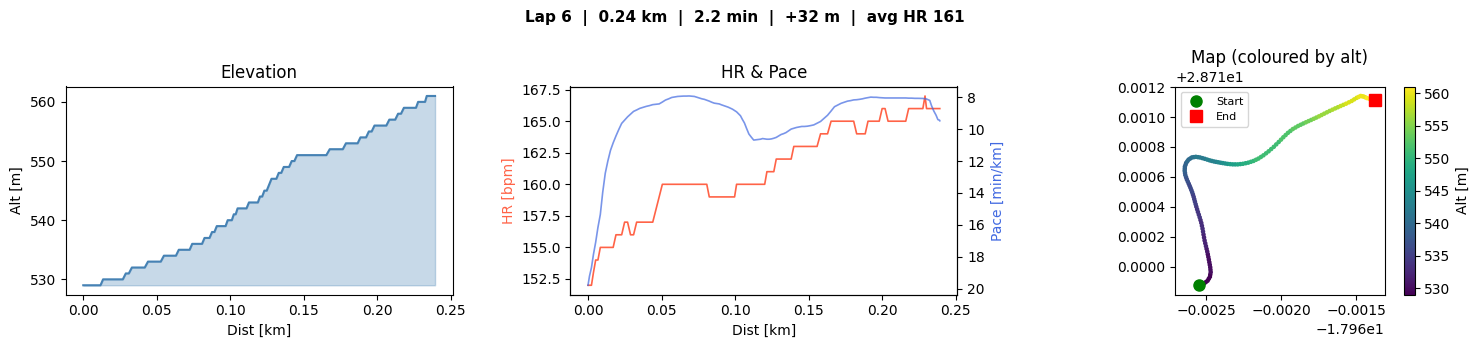

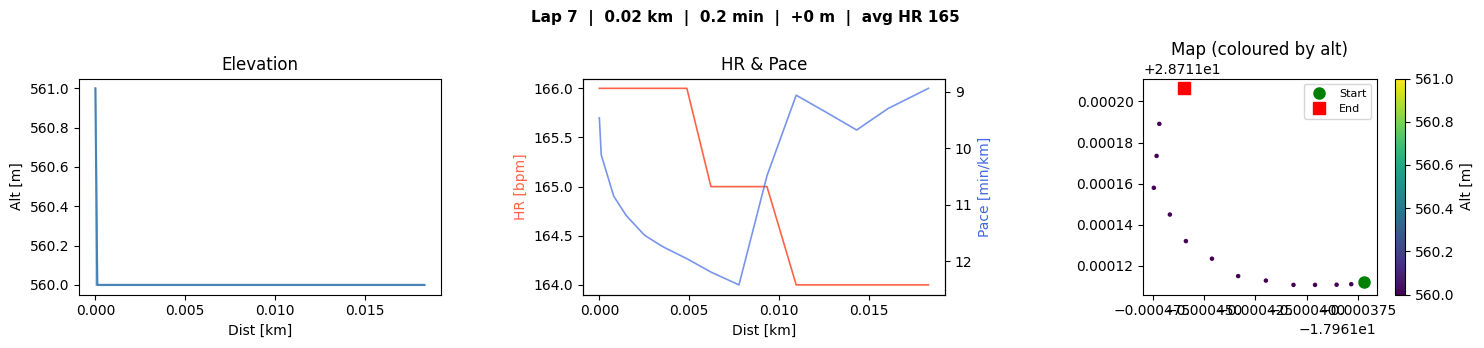

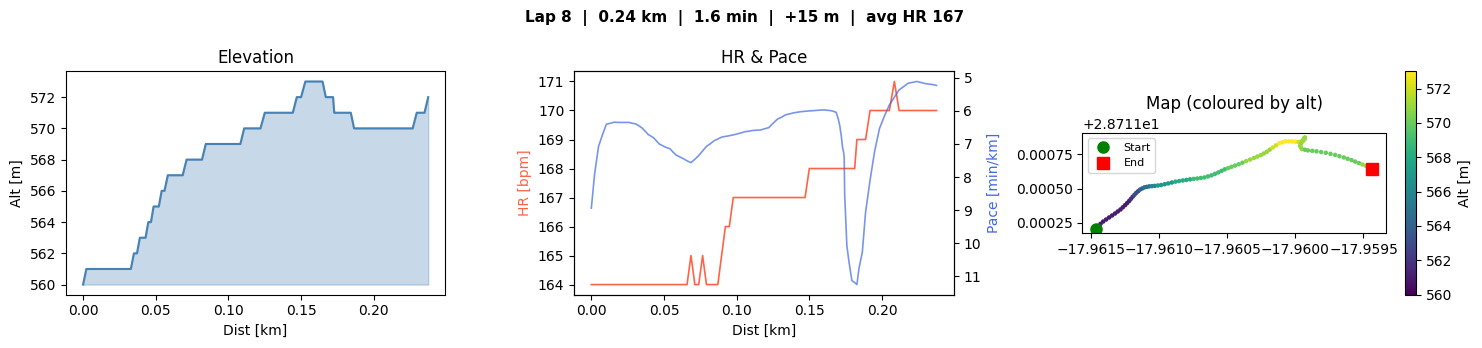

2026-05-17 16:58:59+00:00


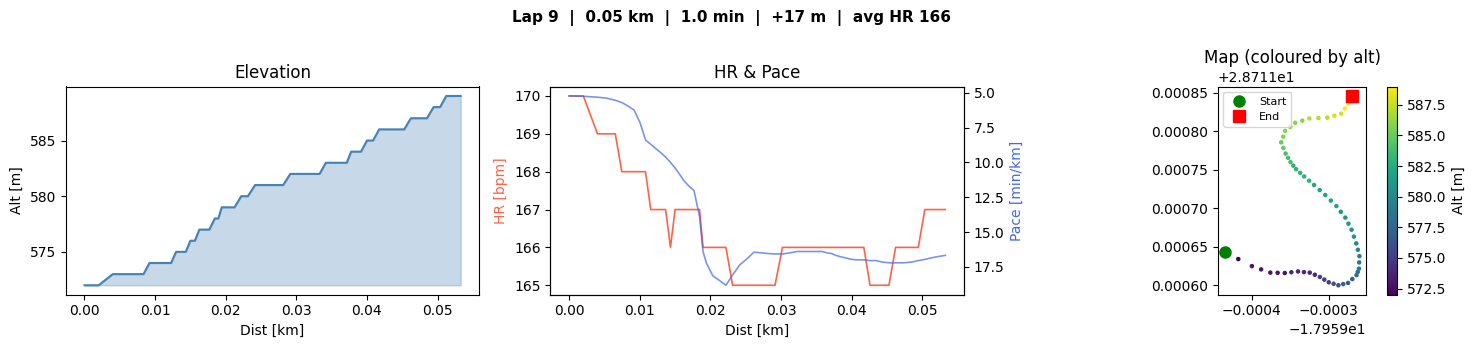

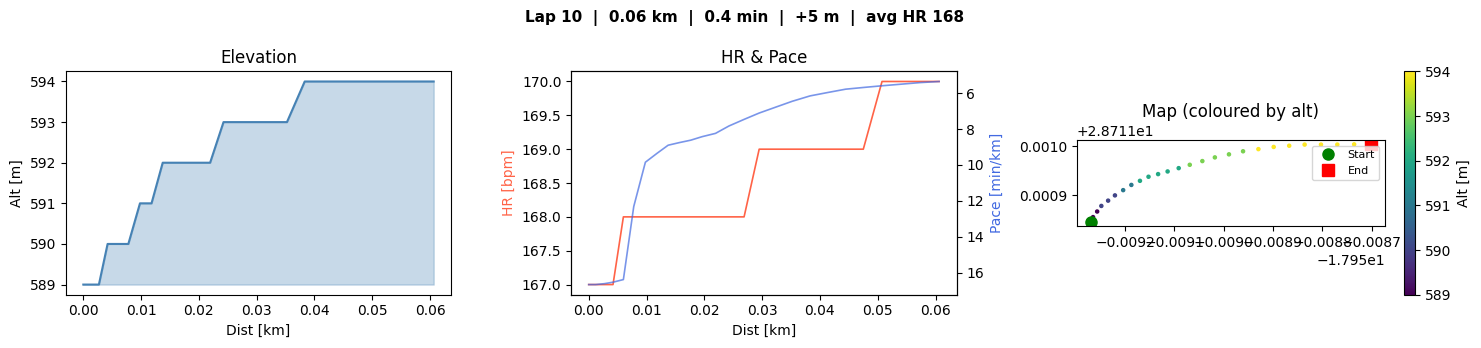

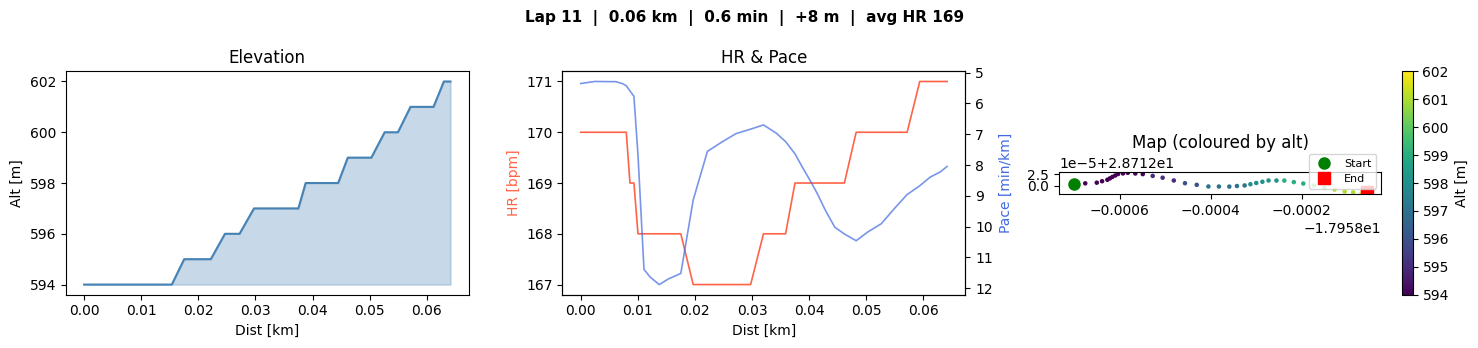

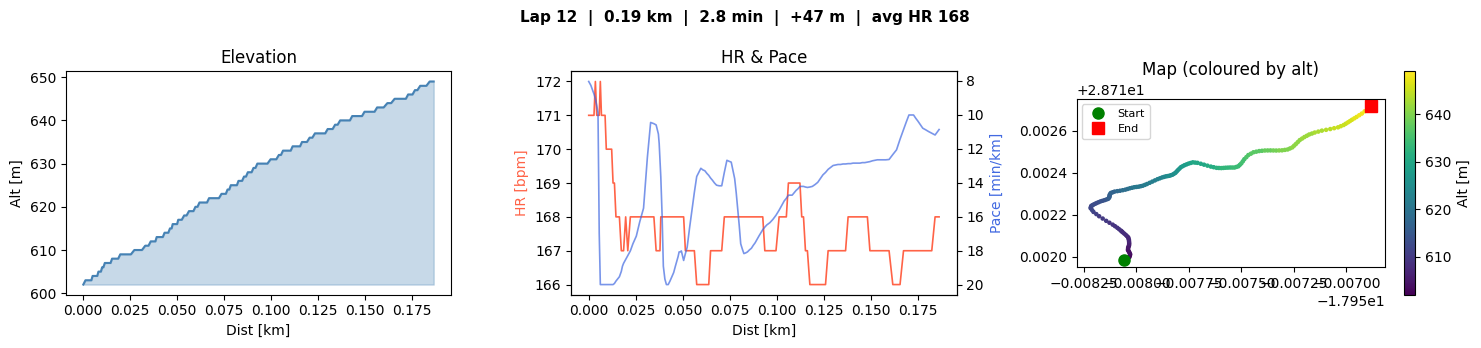

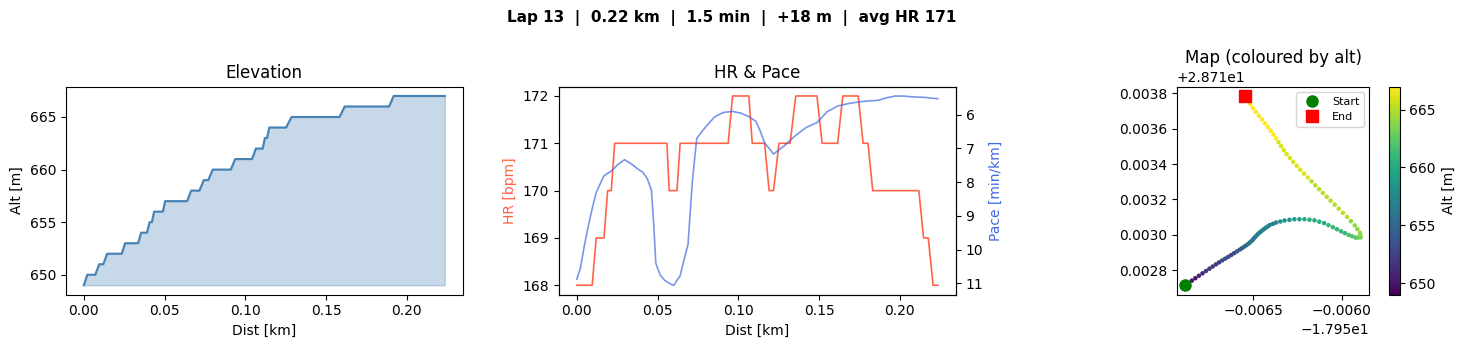

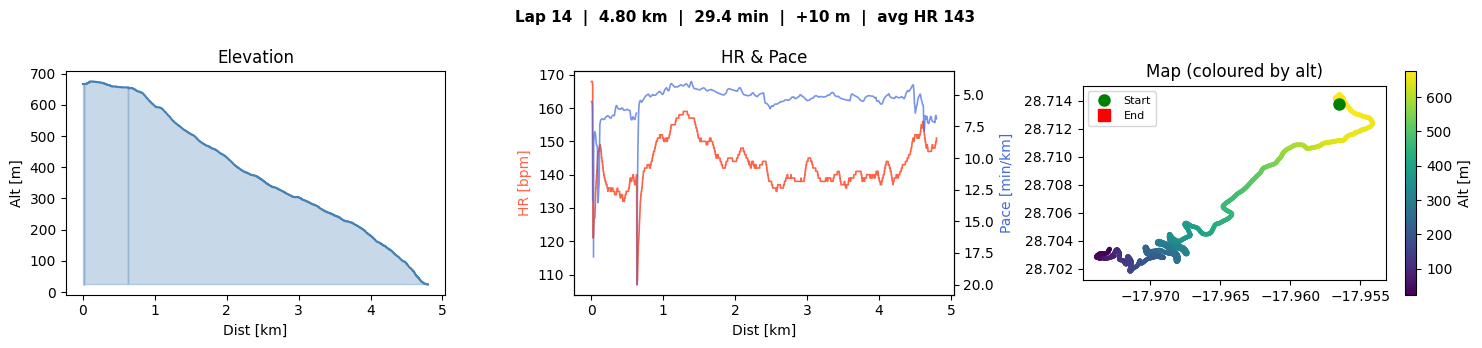

In [126]:
# ── CONFIG ────────────────────────────────────────────────────
LAPS_TO_PLOT = None   # None = all laps; or list like [0, 1, 3] to pick specific ones
# ──────────────────────────────────────────────────────────────

lap_ids = laps_df['lap'].tolist() if LAPS_TO_PLOT is None else LAPS_TO_PLOT

for i in lap_ids:
    row = laps_df[laps_df['lap'] == i].iloc[0]
    mask = (df['timestamp'] >= row['start_time']) & (df['timestamp'] <= row['end_time'])
    if i == 9: 
        print(row['start_time'])
    sub = df[mask].copy()
    if sub.empty:
        print(f'Lap {i}: no data'); continue

    sub['rel_dist'] = sub['dist_km'] - sub['dist_km'].iloc[0]

    fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
    fig.suptitle(f'Lap {i}  |  {row["dist_km"]:.2f} km  |  {row["duration_min"]:.1f} min  |  +{row["elev_gain"]:.0f} m  |  avg HR {row["avg_hr"]:.0f}',
                 fontsize=11, fontweight='bold')

    # Elevation
    axes[0].fill_between(sub['rel_dist'], sub['alt'], sub['alt'].min(), alpha=0.3, color='steelblue')
    axes[0].plot(sub['rel_dist'], sub['alt'], 'steelblue', lw=1.5)
    axes[0].set_xlabel('Dist [km]'); axes[0].set_ylabel('Alt [m]'); axes[0].set_title('Elevation')

    # HR + Pace
    if 'hr' in sub.columns:
        axes[1].plot(sub['rel_dist'], sub['hr'], 'tomato', lw=1.2, label='HR')
        axes[1].set_ylabel('HR [bpm]', color='tomato')
        ax2b = axes[1].twinx()
        if 'pace' in sub.columns:
            ax2b.plot(sub['rel_dist'], sub['pace'].clip(0, 20), 'royalblue', lw=1.2, alpha=0.7, label='Pace')
            ax2b.set_ylabel('Pace [min/km]', color='royalblue')
            ax2b.invert_yaxis()
    axes[1].set_xlabel('Dist [km]'); axes[1].set_title('HR & Pace')

    # Map
    sc = axes[2].scatter(sub['lon'], sub['lat'], c=sub['alt'], cmap='viridis', s=5)
    plt.colorbar(sc, ax=axes[2], label='Alt [m]')
    axes[2].plot(sub['lon'].iloc[0], sub['lat'].iloc[0], 'go', ms=8, label='Start')
    axes[2].plot(sub['lon'].iloc[-1], sub['lat'].iloc[-1], 'rs', ms=8, label='End')
    axes[2].legend(fontsize=8); axes[2].set_aspect('equal')
    axes[2].set_title('Map (coloured by alt)')

    plt.tight_layout()
    plt.savefig(f'lap_{i:02d}_detail.png', dpi=120, bbox_inches='tight')
    plt.show()

## 6 — Manual cut / merge editor

Use `SEGMENT_DEFS` to define your final segments from scratch.  
Each entry is a dict with:
- `name`: your segment label  
- `source`: `'laps'` (list of lap ids) **or** `'time'` (manual time window)  
- `laps`: list of lap ids to join (when source=`'laps'`)  
- `t_start` / `t_end`: ISO strings or offsets in seconds from start (when source=`'time'`)  
- `terrain`: free-text tag e.g. `'uphill-steep'`, `'flat'`, `'downhill-technical'`

**Example — you got lost in the middle of lap 2, so you cut it into two clean parts:**

In [155]:
# ── EDIT THIS BLOCK ───────────────────────────────────────────
# Reference: print laps_df above to get lap indices and start/end times

SEGMENT_DEFS = [
    # Example: merge laps 0 and 1 as one climb segment
    dict(name='Segment 1 Empedrat',   source='time', 
         t_start="2026-05-17 16:22:22", t_end="2026-05-17 16:38:14",  terrain='uphill-steep'),
    dict(name='Segment 2 Pared pedra',   source='laps', laps=[1],  terrain='uphill-technical'),
    dict(name='Segment 3 Pedra solta i terra',   source='time',  
         t_start='2026-05-17 16:43:27', t_end='2026-05-17 16:51:05', terrain='uphill-moderate'),
    dict(name='Segment 4 Paviment',   source='time',  
         t_start='2026-05-17T16:54:29', t_end='2026-05-17T16:56:56', terrain='uphill-steep'),
    dict(name='Segment 5 Corriol de terra',   source='time',  
         t_start='2026-05-17T16:57:16', t_end='2026-05-17 16:58:59', terrain='flat'),
    dict(name='Segment 6 Trepada final',   source='laps', laps=[9, 10, 11, 12], terrain='uphill-steep'),
    dict(name='Segment 7 final',   source='laps', laps=[13], terrain='flat'),
]
# ──────────────────────────────────────────────────────────────

print(f'{len(SEGMENT_DEFS)} segments defined')

7 segments defined


In [156]:
def extract_segment(df, laps_df, seg_def):
    """Return a slice of df for a given segment definition."""
    if seg_def['source'] == 'laps':
        masks = []
        for lap_id in seg_def['laps']:
            row = laps_df[laps_df['lap'] == lap_id]
            if row.empty:
                print(f'  WARNING: lap {lap_id} not found'); continue
            row = row.iloc[0]
            
            # FIX 1: Force start and end times to be UTC-aware
            start_t = pd.to_datetime(row['start_time']).tz_localize('UTC') if pd.to_datetime(row['start_time']).tzinfo is None else pd.to_datetime(row['start_time']).tz_convert('UTC')
            end_t = pd.to_datetime(row['end_time']).tz_localize('UTC') if pd.to_datetime(row['end_time']).tzinfo is None else pd.to_datetime(row['end_time']).tz_convert('UTC')
            
            masks.append((df['timestamp'] >= start_t) & (df['timestamp'] <= end_t))
        if not masks: return pd.DataFrame()
        combined = masks[0]
        for m in masks[1:]: combined = combined | m
        return df[combined].copy()

    elif seg_def['source'] == 'time':
        # FIX 2: Use dt.tz_localize('UTC') to ensure these strings are parsed as UTC
        t0 = pd.to_datetime(seg_def['t_start']).tz_localize('UTC')
        t1 = pd.to_datetime(seg_def['t_end']).tz_localize('UTC')
        return df[(df['timestamp'] >= t0) & (df['timestamp'] <= t1)].copy()

    else:
        raise ValueError(f"Unknown source: {seg_def['source']}")


# Build all segments
segments = []
for seg_def in SEGMENT_DEFS:
    sub = extract_segment(df, laps_df, seg_def)
    if sub.empty:
        print(f'  EMPTY: {seg_def["name"]}')
        continue
    sub = sub.reset_index(drop=True)
    sub['rel_dist'] = sub['dist_km'] - sub['dist_km'].iloc[0]
    elev_gain = sub['alt'].diff().clip(lower=0).sum() if 'alt' in sub else 0
    elev_loss = sub['alt'].diff().clip(upper=0).sum() if 'alt' in sub else 0
    duration_min = (sub['timestamp'].iloc[-1] - sub['timestamp'].iloc[0]).total_seconds() / 60
    segments.append({
        'name':     seg_def['name'],
        'terrain':  seg_def.get('terrain', ''),
        'data':     sub,
        'dist_km':  sub['rel_dist'].max(),
        'elev_gain': elev_gain,
        'elev_loss': elev_loss,
        'duration_min': duration_min,
        'avg_hr':   sub['hr'].mean() if 'hr' in sub else np.nan,
    })
    print(f"✓ {seg_def['name']:35s}  {sub['rel_dist'].max():.2f} km  +{elev_gain:.0f}m  {elev_loss:.0f}m  {duration_min:.1f} min")
print(f'\n{len(segments)} segments built')

✓ Segment 1 Empedrat                   1.07 km  +301m  0m  15.9 min
✓ Segment 2 Pared pedra                0.26 km  +88m  0m  5.2 min
✓ Segment 3 Pedra solta i terra        0.63 km  +110m  0m  7.6 min
✓ Segment 4 Paviment                   0.26 km  +37m  0m  2.5 min
✓ Segment 5 Corriol de terra           0.24 km  +15m  -3m  1.7 min
✓ Segment 6 Trepada final              0.36 km  +77m  0m  4.8 min
✓ Segment 7 final                      0.22 km  +18m  0m  1.5 min

7 segments built


## 7 — Plot all final segments

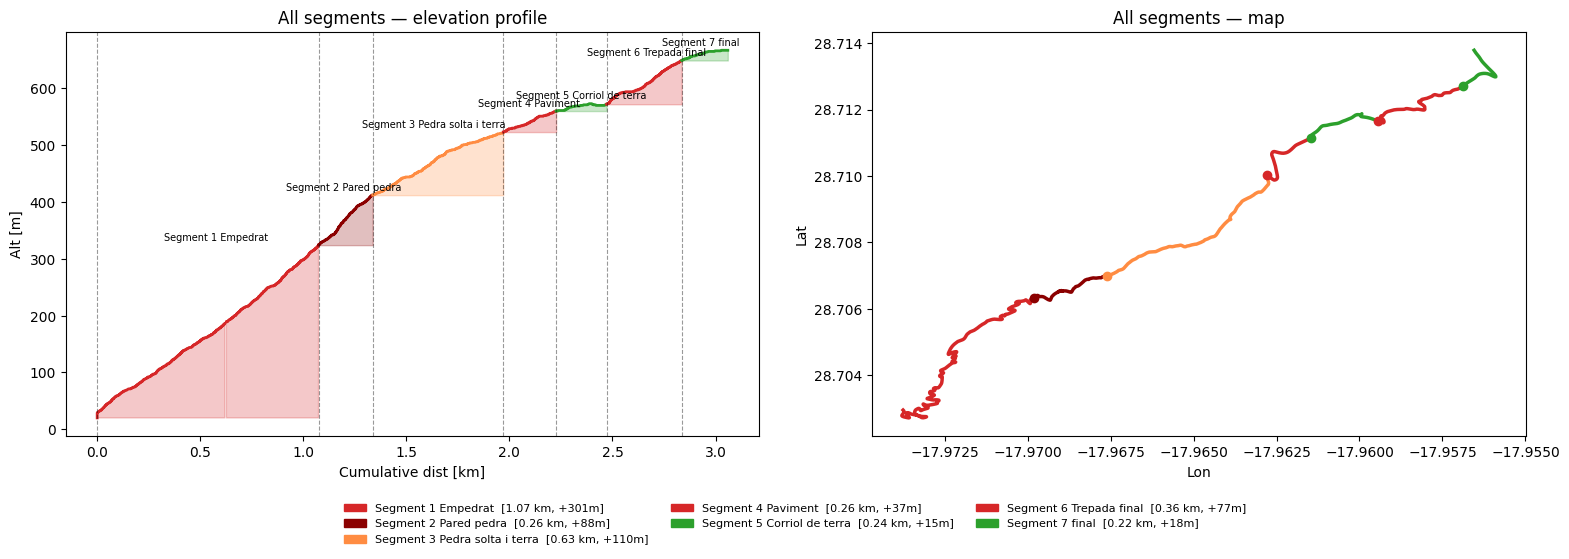

In [157]:
TERRAIN_COLORS = {
    'uphill-moderate':   '#ff8c42',
    'uphill-steep':      '#d62728',
    'uphill-technical':  '#8b0000',
    'downhill-easy':     '#8fd3ff',
    'downhill-steep':    '#2a5aa0',
    'downhill-technical':'#1a3e5c',
    'flat':              '#2ca02c',
}
DEFAULT_COLOR = '#888888'

# ── Stacked elevation overview ──────────────────────────────
fig, (ax_elev, ax_map) = plt.subplots(1, 2, figsize=(16, 5))

offset = 0.0
patches = []
for seg in segments:
    sub = seg['data']
    color = TERRAIN_COLORS.get(seg['terrain'], DEFAULT_COLOR)
    x = sub['rel_dist'] + offset

    ax_elev.fill_between(x, sub['alt'], sub['alt'].min(), alpha=0.25, color=color)
    ax_elev.plot(x, sub['alt'], color=color, lw=2)
    ax_elev.axvline(offset, color='k', lw=0.8, ls='--', alpha=0.4)
    mid_x = x.iloc[len(x)//2]
    ax_elev.text(mid_x, sub['alt'].max() + 5, seg['name'].split('–')[-1].strip(),
                 fontsize=7, ha='center', va='bottom', rotation=0)

    ax_map.plot(sub['lon'], sub['lat'], color=color, lw=2.5)
    ax_map.plot(sub['lon'].iloc[0], sub['lat'].iloc[0], 'o', color=color, ms=6, zorder=5)

    patches.append(mpatches.Patch(color=color,
        label=f"{seg['name']}  [{seg['dist_km']:.2f} km, +{seg['elev_gain']:.0f}m]"))
    offset += seg['dist_km']

ax_elev.set_xlabel('Cumulative dist [km]'); ax_elev.set_ylabel('Alt [m]')
ax_elev.set_title('All segments — elevation profile')
ax_map.set_xlabel('Lon'); ax_map.set_ylabel('Lat')
ax_map.set_title('All segments — map')
ax_map.set_aspect('equal')
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=8,
           frameon=False, bbox_to_anchor=(0.5, -0.12))
plt.tight_layout()
plt.savefig('all_segments_overview.png', dpi=150, bbox_inches='tight')
plt.show()

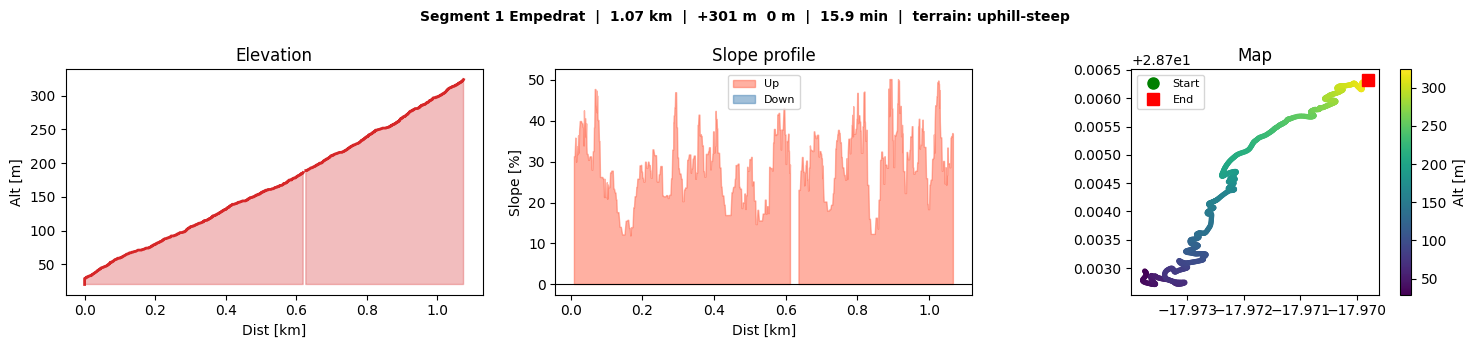

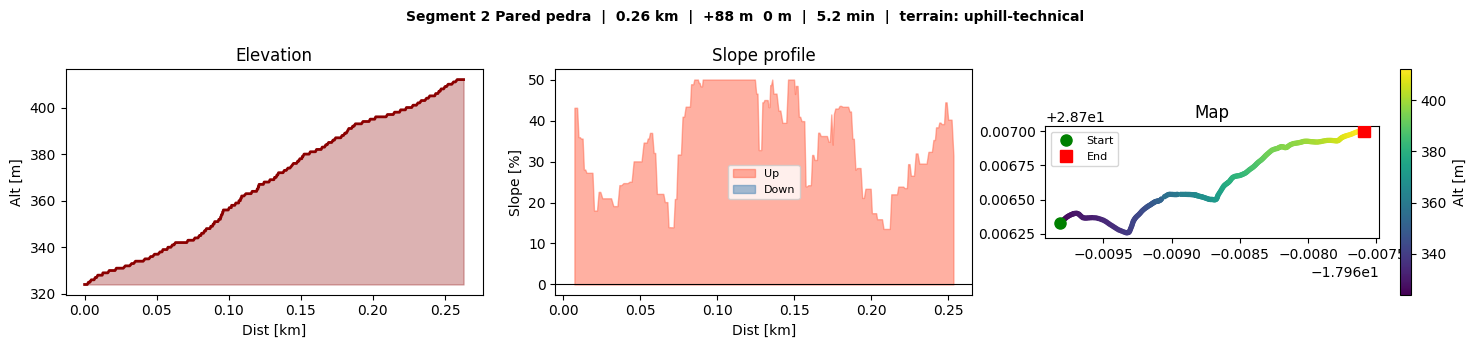

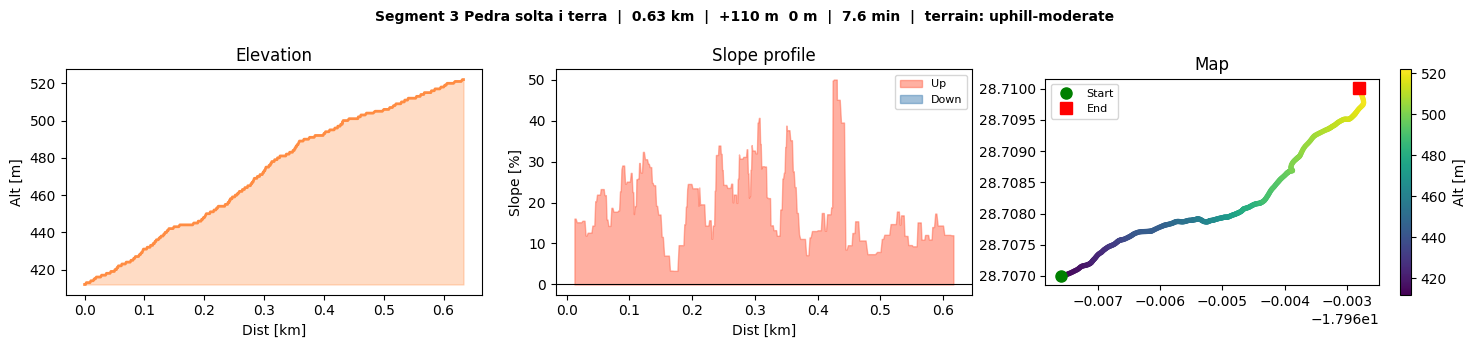

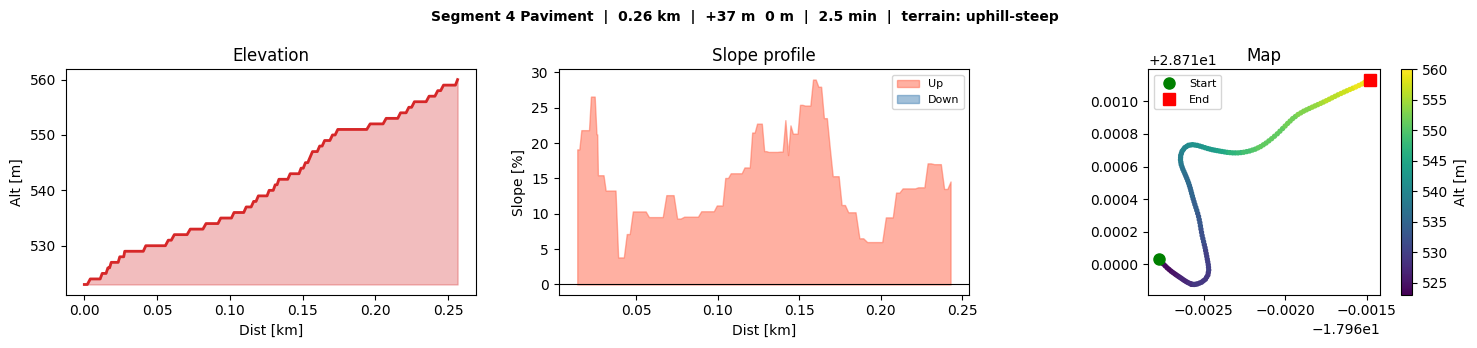

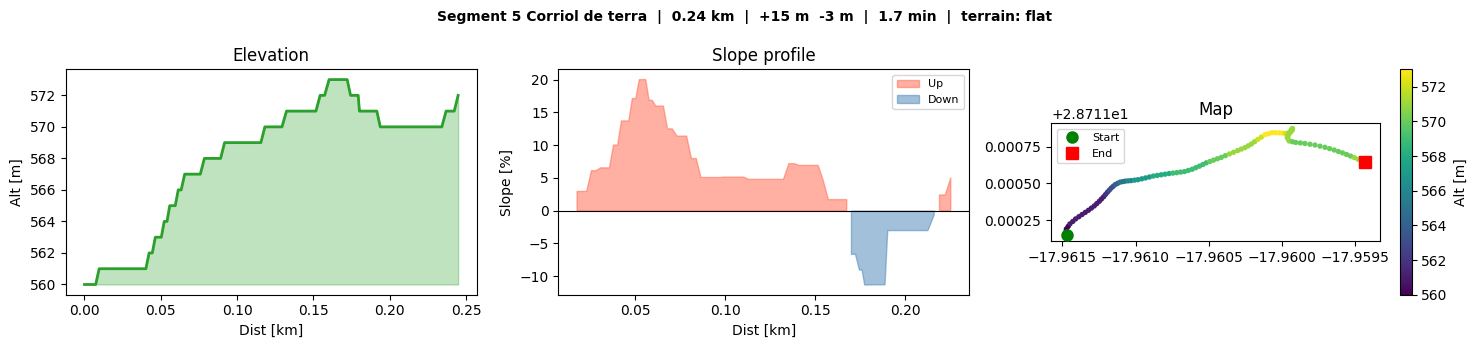

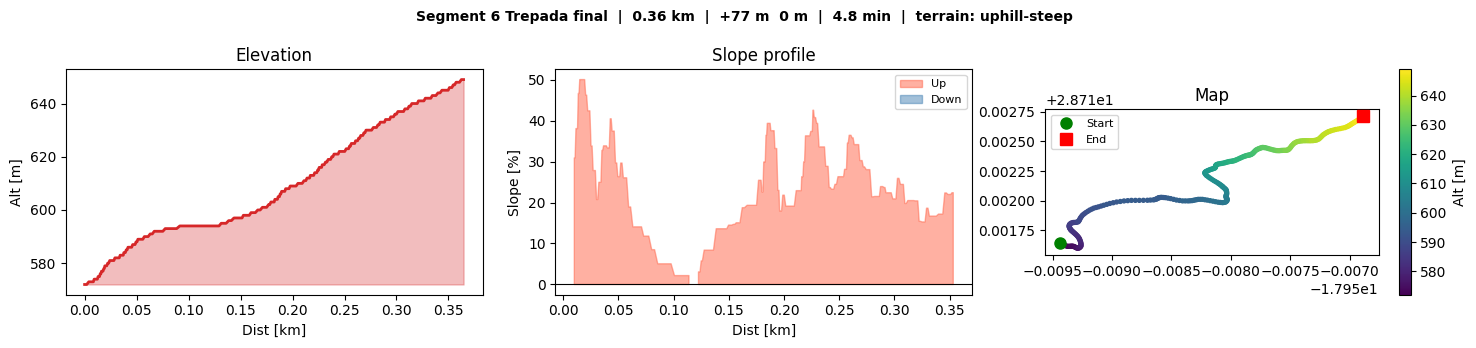

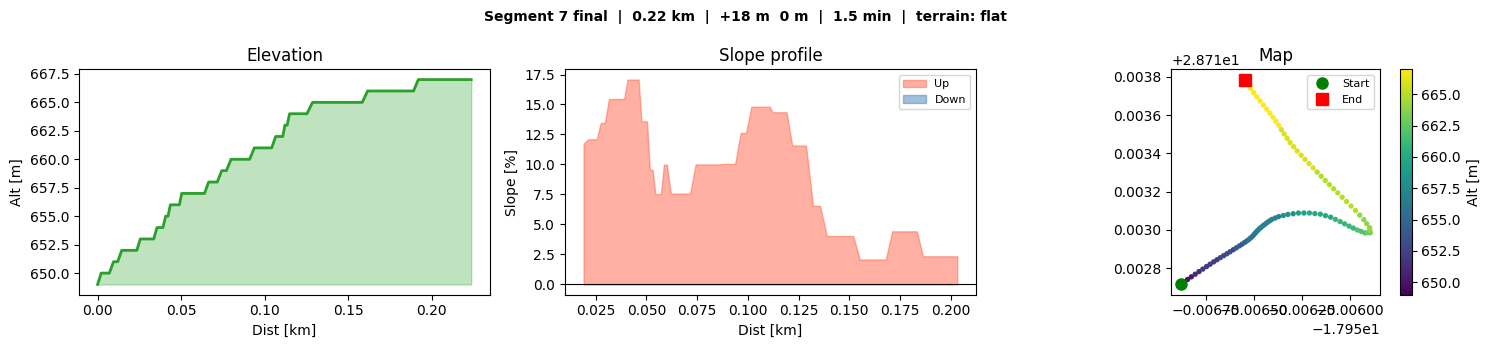

In [158]:
# ── Per-segment detail cards ─────────────────────────────────
for seg in segments:
    sub = seg['data']
    color = TERRAIN_COLORS.get(seg['terrain'], DEFAULT_COLOR)

    fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
    title = (f"{seg['name']}  |  {seg['dist_km']:.2f} km  |  "
             f"+{seg['elev_gain']:.0f} m  {seg['elev_loss']:.0f} m  |  "
             f"{seg['duration_min']:.1f} min  |  terrain: {seg['terrain']}")
    fig.suptitle(title, fontsize=10, fontweight='bold')

    # Elevation
    axes[0].fill_between(sub['rel_dist'], sub['alt'], sub['alt'].min(), alpha=0.3, color=color)
    axes[0].plot(sub['rel_dist'], sub['alt'], color=color, lw=2)
    axes[0].set_xlabel('Dist [km]'); axes[0].set_ylabel('Alt [m]'); axes[0].set_title('Elevation')

    # Slope
    if 'alt' in sub.columns and 'dist_km' in sub.columns:
        ddist = (sub['dist_km'].diff() * 1000).fillna(0)

        dalt  = sub['alt'].diff()
        slope = (dalt / ddist.replace(0, np.nan) * 100)
        slope_smooth = slope.rolling(15, center=True).mean().clip(-50, 50)
        axes[1].fill_between(sub['rel_dist'], slope_smooth, 0,
                             where=slope_smooth > 0, alpha=0.5, color='tomato', label='Up')
        axes[1].fill_between(sub['rel_dist'], slope_smooth, 0,
                             where=slope_smooth < 0, alpha=0.5, color='steelblue', label='Down')
        axes[1].axhline(0, color='k', lw=0.8)
        axes[1].set_xlabel('Dist [km]'); axes[1].set_ylabel('Slope [%]')
        axes[1].set_title('Slope profile'); axes[1].legend(fontsize=8)

    # Map
    sc = axes[2].scatter(sub['lon'], sub['lat'], c=sub['alt'], cmap='viridis', s=8, zorder=2)
    plt.colorbar(sc, ax=axes[2], label='Alt [m]')
    axes[2].plot(sub['lon'].iloc[0],  sub['lat'].iloc[0],  'go', ms=8, label='Start', zorder=5)
    axes[2].plot(sub['lon'].iloc[-1], sub['lat'].iloc[-1], 'rs', ms=8, label='End',   zorder=5)
    axes[2].legend(fontsize=8); axes[2].set_aspect('equal')
    axes[2].set_title('Map')

    plt.tight_layout()
    safe_name = seg['name'].replace(' ', '_').replace('–','').replace('/','-')
    plt.savefig(f'segment_{safe_name}.png', dpi=120, bbox_inches='tight')
    plt.show()

## 8 — Segment summary table

In [146]:
summary = pd.DataFrame([{
    'Segment':      s['name'],
    'Terrain':      s['terrain'],
    'Dist [km]':    round(s['dist_km'], 2),
    '+Elev [m]':    round(s['elev_gain'], 0),
    '-Elev [m]':    round(abs(s['elev_loss']), 0),
    'Dur [min]':    round(s['duration_min'], 1),
    'Avg HR':       round(s['avg_hr'], 0),
    'D+ /km':       round(s['elev_gain'] / s['dist_km'], 1) if s['dist_km'] > 0 else 0,
    'Slope':      round((s['elev_gain'] / (s['dist_km'] * 1000)) * 100, 1) if s['dist_km'] > 0 else 0,
} for s in segments])

display(summary.drop(columns=["Dur [min]", "Avg HR"]))

print(f"\nTOTAL  {summary['Dist [km]'].sum():.2f} km  "
      f"+{summary['+Elev [m]'].sum():.0f} m  "
      f"{summary['Dur [min]'].sum():.0f} min")

,Segment,Terrain,Dist [km],+Elev [m],-Elev [m],D+ /km,Slope
0,Segment 1 Empedrat,empedrat-inclinat,1.07,301.00,0.00,280.30,28.00
1,Segment 2 Pared pedra,pedra-solida-inclinat,0.26,88.00,0.00,334.80,33.50
2,Segment 3 Pedra solta i terra,pedra-terra-corrible,0.63,110.00,0.00,173.70,17.40
3,Segment 4 Paviment,pavimentat-cement,0.26,37.00,0.00,144.20,14.40
4,Segment 5 Corriol de terra,pavimentat-cement,0.24,15.00,3.00,61.30,6.10
5,Segment 6 Trepada final,Roca-terreny-irregular,0.36,77.00,0.00,211.20,21.10
6,Segment 7 final,asfalt,0.22,18.00,0.00,80.50,8.10



TOTAL  3.04 km  +646 m  39 min


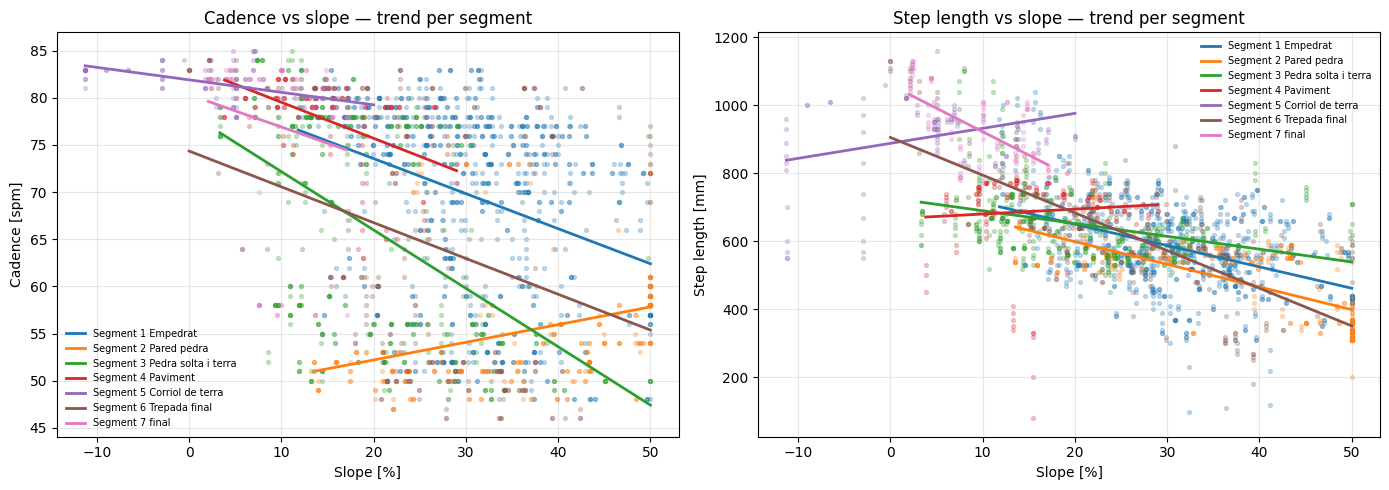

In [152]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, seg in enumerate(segments):
    sub = seg['data']
    if 'cadence' not in sub.columns: continue
    color = f"C{i}" # TERRAIN_COLORS.get(seg['terrain'], DEFAULT_COLOR)
    label = seg['name'].split('–')[-1].strip()

    ddist = sub['dist_km'].diff() * 1000
    dalt  = sub['alt'].diff()
    slope_pct = (dalt / ddist.replace(0, np.nan) * 100).rolling(15, center=True).mean().clip(-50, 50)

    mask = slope_pct.notna() & sub['cadence'].notna()
    axes[0].scatter(slope_pct[mask], sub['cadence'][mask],
                    color=color, alpha=0.25, s=8)
    # Trend line per segment
    if mask.sum() > 10:
        z = np.polyfit(slope_pct[mask], sub['cadence'][mask], 1)
        xs = np.linspace(slope_pct[mask].min(), slope_pct[mask].max(), 50)
        axes[0].plot(xs, np.polyval(z, xs), color=color, lw=2, label=label)

    if 'step_length' in sub.columns:
        mask2 = slope_pct.notna() & sub['step_length'].notna()
        axes[1].scatter(slope_pct[mask2], sub['step_length'][mask2],
                        color=color, alpha=0.25, s=8)
        if mask2.sum() > 10:
            z2 = np.polyfit(slope_pct[mask2], sub['step_length'][mask2], 1)
            xs2 = np.linspace(slope_pct[mask2].min(), slope_pct[mask2].max(), 50)
            axes[1].plot(xs2, np.polyval(z2, xs2), color=color, lw=2, label=label)

axes[0].set_xlabel('Slope [%]'); axes[0].set_ylabel('Cadence [spm]')
axes[0].set_title('Cadence vs slope — trend per segment')
axes[0].legend(fontsize=7, frameon=False); axes[0].grid(alpha=0.3)

axes[1].set_xlabel('Slope [%]'); axes[1].set_ylabel('Step length [mm]')
axes[1].set_title('Step length vs slope — trend per segment')
axes[1].legend(fontsize=7, frameon=False); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.savefig('biomechanics_vs_slope.png', dpi=150, bbox_inches='tight'); plt.show()